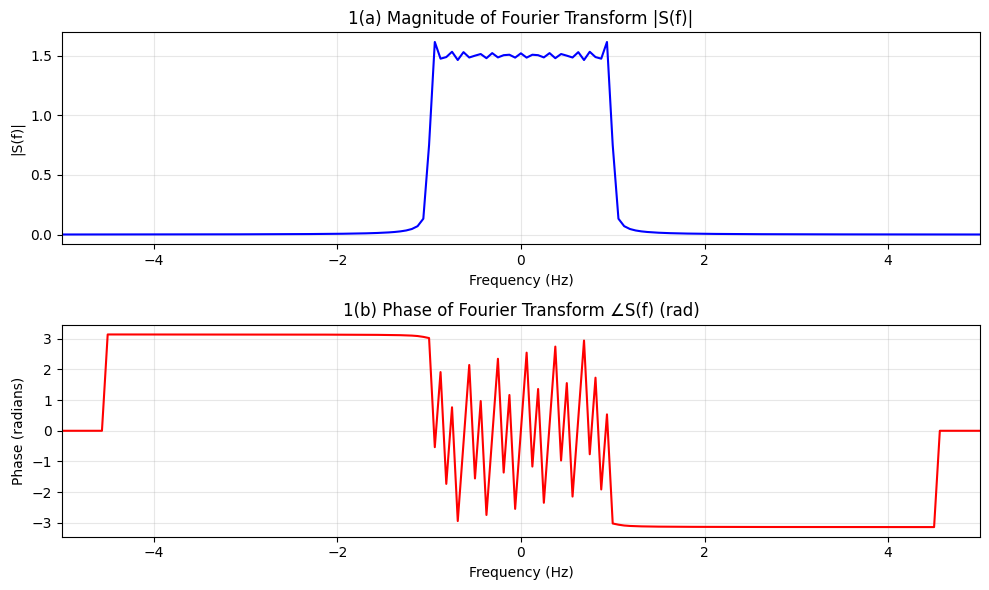

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling parameters
fs = 160                        # 160 Hz
t = np.arange(-8, 8, 1/fs)      # Truncated range [-8, 8] seconds
N = len(t)

# Signal generation: s(t) = 3*sinc(2t - 3)
# np.sinc(x) computes sin(pi*x)/(pi*x)
s = 3 * np.sinc(2*t - 3)

# Numerical Fourier Transform using FFT with shift to center at 0 Hz
S = np.fft.fftshift(np.fft.fft(s)) / fs
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Phase with small value threshold masking to remove numerical noise
phase_S = np.angle(S)
phase_S[np.abs(S) < 1e-3] = 0

# (a) Magnitude Spectrum & (b) Phase Spectrum[cite: 1]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(freqs, np.abs(S), 'b', lw=1.5)
ax1.set_xlim(-5, 5)
ax1.set_title('1(a) Magnitude of Fourier Transform |S(f)|')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('|S(f)|')
ax1.grid(True, alpha=0.3)

ax2.plot(freqs, phase_S, 'r', lw=1.5)
ax2.set_xlim(-5, 5)
ax2.set_title('1(b) Phase of Fourier Transform ∠S(f) (rad)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Phase (radians)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

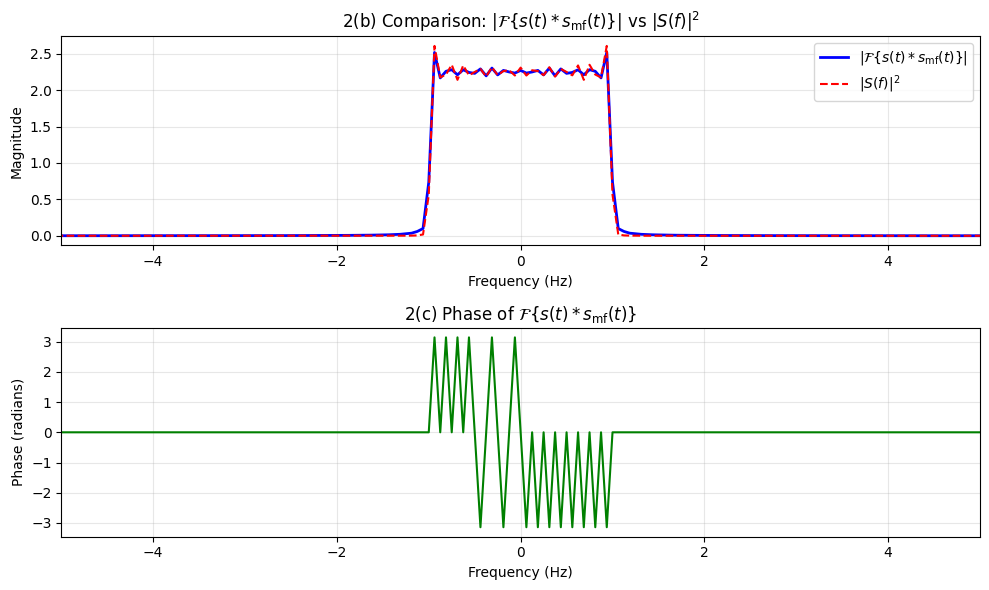

In [2]:
# Matched filter impulse response: s_mf(t) = s(-t)
s_mf = np.flip(s)

# Numerical Convolution: s(t) * s_mf(t)[cite: 1]
# Scaled by dt (1/fs) to match continuous-time integration
conv_s = np.convolve(s, s_mf, mode='same') * (1/fs)

# Fourier Transform of convolution result[cite: 1]
F_conv = np.fft.fftshift(np.fft.fft(conv_s)) / fs
phase_conv = np.angle(F_conv)
phase_conv[np.abs(F_conv) < 1e-3] = 0

# |S(f)|^2 for comparison[cite: 1]
S_mag_sq = np.abs(S)**2

# Plots[cite: 1]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# (b) Comparison: |F{s * s_mf}| vs |S(f)|^2[cite: 1]
ax1.plot(freqs, np.abs(F_conv), 'b', lw=2, label=r'$|\mathcal{F}\{s(t)*s_{\mathrm{mf}}(t)\}|$')
ax1.plot(freqs, S_mag_sq, 'r--', lw=1.5, label=r'$|S(f)|^2$')
ax1.set_xlim(-5, 5)
ax1.set_title(r'2(b) Comparison: $|\mathcal{F}\{s(t)*s_{\mathrm{mf}}(t)\}|$ vs $|S(f)|^2$')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

# (c) Phase of F{s * s_mf}[cite: 1]
ax2.plot(freqs, phase_conv, 'g', lw=1.5)
ax2.set_xlim(-5, 5)
ax2.set_title(r'2(c) Phase of $\mathcal{F}\{s(t)*s_{\mathrm{mf}}(t)\}$')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Phase (radians)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

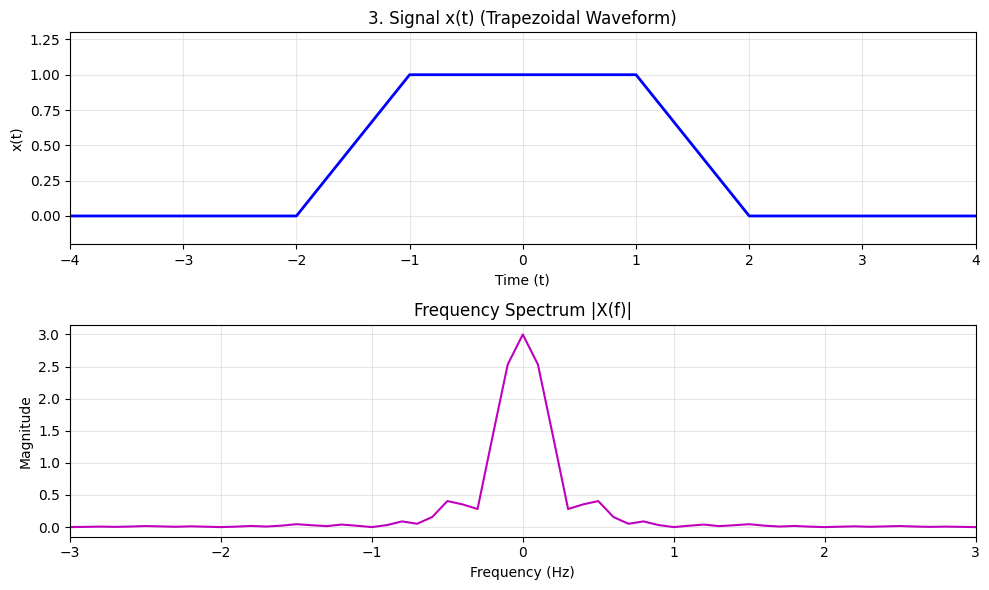

In [3]:
fs = 100
t = np.arange(-5, 5, 1/fs)

# Piecewise definition of x(t)
conditions = [
    (t >= -2) & (t <= -1),
    (t > -1) & (t <= 1),
    (t > 1) & (t <= 2)
]
choices = [
    t + 2,
    1.0,
    -t + 2
]
x = np.select(conditions, choices, default=0.0)

# Spectrum computation
N = len(t)
X = np.fft.fftshift(np.fft.fft(x)) / fs
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(t, x, 'b', lw=2)
ax1.set_xlim(-4, 4)
ax1.set_ylim(-0.2, 1.3)
ax1.set_title('3. Signal x(t) (Trapezoidal Waveform)')
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('x(t)')
ax1.grid(True, alpha=0.3)

ax2.plot(freqs, np.abs(X), 'm', lw=1.5)
ax2.set_xlim(-3, 3)
ax2.set_title('Frequency Spectrum |X(f)|')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

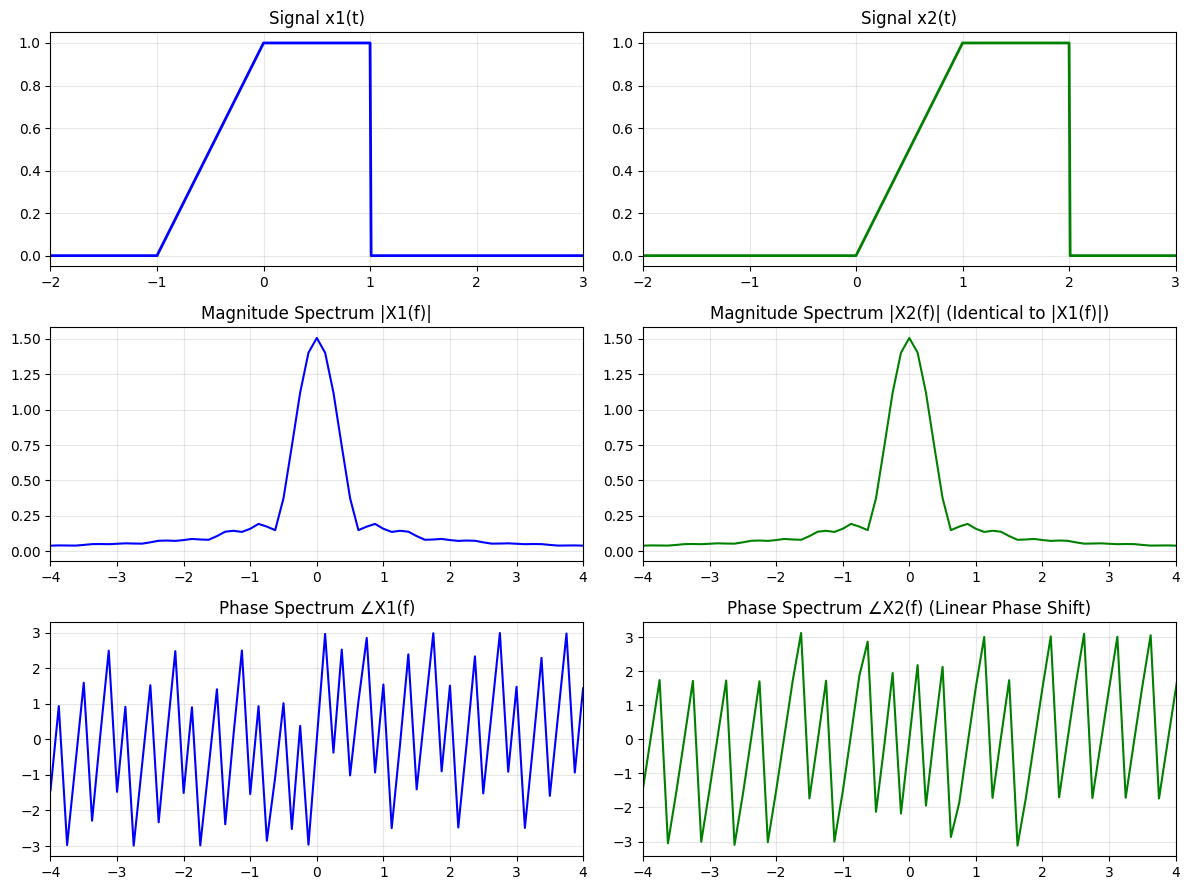

In [4]:
fs = 100
t = np.arange(-4, 4, 1/fs)
N = len(t)
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Define x1(t)[cite: 2]
x1 = np.select([(t >= -1) & (t <= 0), (t > 0) & (t <= 1)], [t + 1, 1.0], default=0.0)

# Define x2(t)[cite: 2]
x2 = np.select([(t >= 0) & (t <= 1), (t > 1) & (t <= 2)], [t, 1.0], default=0.0)

# Compute FFTs
X1 = np.fft.fftshift(np.fft.fft(x1)) / fs
X2 = np.fft.fftshift(np.fft.fft(x2)) / fs

# Mask phase for small magnitude values
phase_X1 = np.angle(X1)
phase_X1[np.abs(X1) < 1e-2] = 0

phase_X2 = np.angle(X2)
phase_X2[np.abs(X2) < 1e-2] = 0

# Plotting[cite: 2]
fig, axes = plt.subplots(3, 2, figsize=(12, 9))

# Time domain[cite: 2]
axes[0, 0].plot(t, x1, 'b', lw=2)
axes[0, 0].set_title('Signal x1(t)')
axes[0, 0].set_xlim(-2, 3)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t, x2, 'g', lw=2)
axes[0, 1].set_title('Signal x2(t)')
axes[0, 1].set_xlim(-2, 3)
axes[0, 1].grid(True, alpha=0.3)

# Magnitude spectra[cite: 2]
axes[1, 0].plot(freqs, np.abs(X1), 'b', lw=1.5)
axes[1, 0].set_title('Magnitude Spectrum |X1(f)|')
axes[1, 0].set_xlim(-4, 4)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(freqs, np.abs(X2), 'g', lw=1.5)
axes[1, 1].set_title('Magnitude Spectrum |X2(f)| (Identical to |X1(f)|)')
axes[1, 1].set_xlim(-4, 4)
axes[1, 1].grid(True, alpha=0.3)

# Phase spectra[cite: 2]
axes[2, 0].plot(freqs, phase_X1, 'b', lw=1.5)
axes[2, 0].set_title('Phase Spectrum ∠X1(f)')
axes[2, 0].set_xlim(-4, 4)
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(freqs, phase_X2, 'g', lw=1.5)
axes[2, 1].set_title('Phase Spectrum ∠X2(f) (Linear Phase Shift)')
axes[2, 1].set_xlim(-4, 4)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

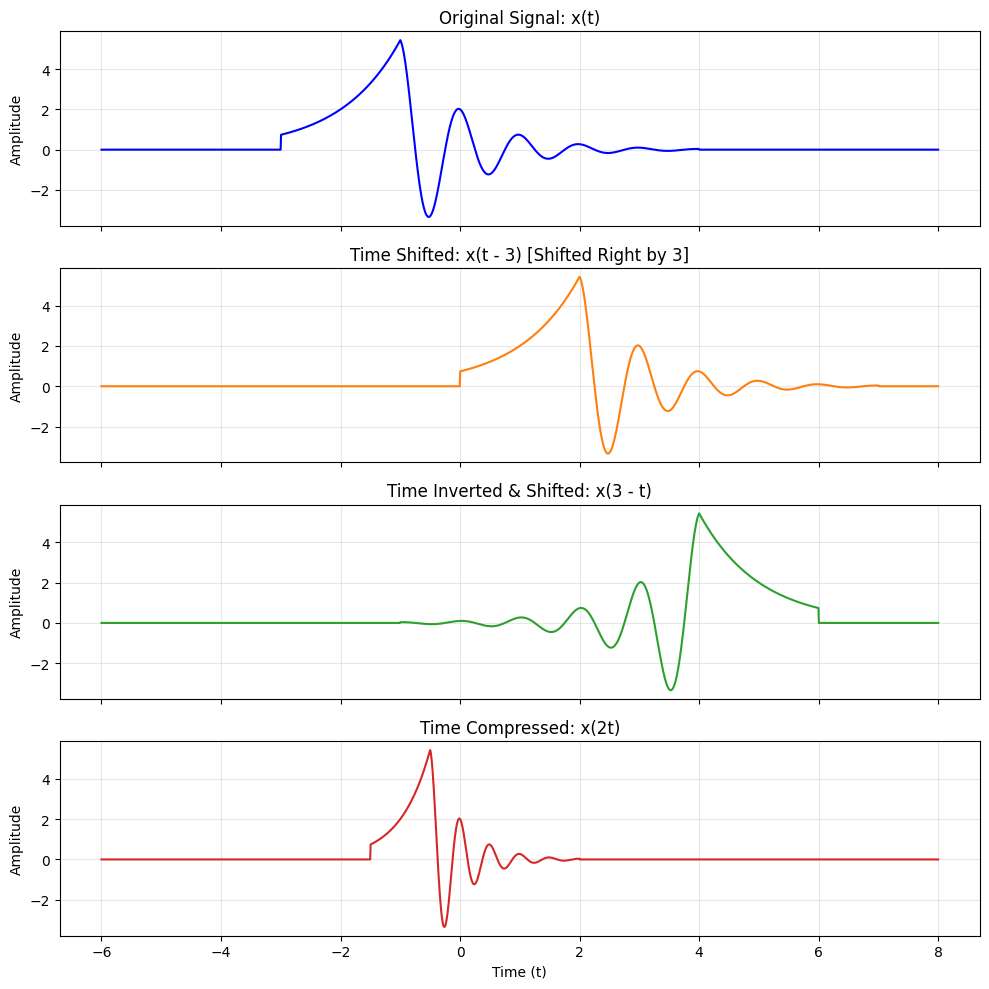

In [5]:
# Helper function to compute x(tau) at any arbitrary time array
def x_func(tau):
    conds = [
        (tau >= -3) & (tau <= -1),
        (tau > -1) & (tau <= 4)
    ]
    exprs = [
        2 * np.exp(tau + 2),
        2 * np.exp(-tau) * np.cos(2 * np.pi * tau)
    ]
    return np.select(conds, exprs, default=0.0)

t = np.linspace(-6, 8, 2000)

# Evaluate transformations[cite: 3]
x_orig = x_func(t)          # x(t)[cite: 3]
x_shift = x_func(t - 3)     # x(t - 3)[cite: 3]
x_rev = x_func(3 - t)       # x(3 - t)[cite: 3]
x_scale = x_func(2 * t)     # x(2t)[cite: 3]

# Plotting all four transformations[cite: 3]
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(t, x_orig, 'b', lw=1.5)
axes[0].set_title('Original Signal: x(t)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x_shift, 'tab:orange', lw=1.5)
axes[1].set_title('Time Shifted: x(t - 3) [Shifted Right by 3]')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, x_rev, 'tab:green', lw=1.5)
axes[2].set_title('Time Inverted & Shifted: x(3 - t)')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)

axes[3].plot(t, x_scale, 'tab:red', lw=1.5)
axes[3].set_title('Time Compressed: x(2t)')
axes[3].set_xlabel('Time (t)')
axes[3].set_ylabel('Amplitude')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()